In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow
import seaborn as sb

In [2]:
features_df = pd.read_parquet(r"C:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\PopocatepetlVolcano\data\features.parquet", engine="pyarrow")

In [3]:
features_df

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index
0,2022-01-01 00:05:00,1.186654e+07,4.305041,None,6743.988806,-0.005959
1,2022-01-01 00:10:00,1.047550e+07,4.293156,None,7043.316623,-0.109812
2,2022-01-01 00:15:00,1.026374e+07,5.644546,None,7175.473832,0.032564
3,2022-01-01 00:20:00,1.024407e+07,5.625740,None,7186.277967,0.065660
4,2022-01-01 00:25:00,9.691936e+06,5.402203,None,7290.097859,-0.179743
...,...,...,...,...,...,...
244232,2024-04-30 23:35:00,4.399604e+08,111.787979,None,1880.653717,0.013671
244233,2024-04-30 23:40:00,4.379600e+08,113.334089,None,1901.904995,0.043806
244234,2024-04-30 23:45:00,2.308502e+08,35.961765,None,2333.147244,0.213128
244235,2024-04-30 23:50:00,2.506737e+08,30.482900,None,2234.924698,0.218329


In [4]:
def geo_mean(iterable):
    a = np.array(iterable)
    return a.prod()**(1.0/len(a))

In [5]:

features_df = pd.read_parquet(r"C:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\PopocatepetlVolcano\data\features.parquet", engine="pyarrow")


# features_df = features_raw_df.copy()
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]


features_df['year'] = pd.DatetimeIndex(features_df['timestamp']).year
features_df['month'] = pd.DatetimeIndex(features_df['timestamp']).month

# Calculate moving average for all features
hours = 24
features_df['kurtosis_mobile_variance'] = features_df['kurtosis'].rolling(window=11*hours, center=True).var()
features_df['kurtosis_mobile_mean'] = features_df['kurtosis'].rolling(window=11*hours, center=True).mean()
features_df['kurtosis_mobile_median'] = features_df['kurtosis'].rolling(window=11*hours, center=True).median()
features_df['kurtosis_mobile_max'] = features_df['kurtosis'].rolling(window=11*hours, center=True).max()
features_df['kurtosis_mobile_q80'] = features_df['kurtosis'].rolling(window=11*hours, center=True).quantile(0.80)
features_df['kurtosis_mobile_geom_mean'] = features_df['kurtosis'].rolling(window=11*hours, center=True).aggregate(geo_mean)


#features_df['kurtosis_mobile_variance_log'] = np.log(features_df['kurtosis_mobile_variance'])

#features_df = features_df[features_df['year']<2024]
#features_df = features_df[(features_df['year']==2023) & (features_df['month']<7) & (features_df['month']>=1)]



In [6]:
fig2, ax21 = plt.subplots(figsize=(11, 6))
ax22 = ax21.twinx()

# Kurtosis
ax21.scatter(features_df['timestamp'], features_df['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label="Ventana de 10 min")
ax21.set_ylabel('Kurtosis', color='black')
ax21.tick_params(axis='y', labelcolor='black')

# Moving variance
ax22.plot(features_df['timestamp'], features_df['kurtosis_mobile_variance'], color='navy', alpha=1, linewidth=2, label=f'Media móvil centrada ({hours} hr)')
ax22.set_ylabel('Varianza móvil', color='navy')
ax22.tick_params(axis='y', labelcolor='navy')
ax22.set_yscale('log')

ax21.set_title('Kurtosis')
ax21.set_xlabel('Fecha')
plt.xticks(rotation=45)
plt.tight_layout()
fig2.savefig(r"C:/Users/LENOVO/OneDrive/Documentos/Estancia de Investigación/PopocatepetlVolcano/img/Kurtosis_mobile_variance.pdf", bbox_inches="tight", dpi=300)
plt.close(fig2)

In [8]:
fig2, ax21 = plt.subplots(figsize=(11, 6))
ax22 = ax21.twinx()

# Kurtosis
ax21.scatter(features_df['timestamp'], features_df['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label="Ventana de 10 min")
ax21.set_ylabel('Kurtosis', color='black')
ax21.tick_params(axis='y', labelcolor='black')

# Moving variance
ax22.plot(features_df['timestamp'], features_df['kurtosis_mobile_mean'], color='navy', alpha=1, linewidth=2, label=f'Media móvil centrada ({hours} hr)')
ax22.set_ylabel('Media móvil', color='navy')
ax22.tick_params(axis='y', labelcolor='navy')
ax22.set_yscale('log')

ax21.set_title('Kurtosis')
ax21.set_xlabel('Fecha')
plt.xticks(rotation=45)
plt.tight_layout()
fig2.savefig(r"C:/Users/LENOVO/OneDrive/Documentos/Estancia de Investigación/PopocatepetlVolcano/img/Kurtosis_mobile_mean.pdf", bbox_inches="tight", dpi=300)
plt.close(fig2)

In [9]:
fig2, ax21 = plt.subplots(figsize=(11, 6))
ax22 = ax21.twinx()

# Kurtosis
ax21.scatter(features_df['timestamp'], features_df['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label="Ventana de 10 min")
ax21.set_ylabel('Kurtosis', color='black')
ax21.tick_params(axis='y', labelcolor='black')

# Moving variance
ax22.plot(features_df['timestamp'], features_df['kurtosis_mobile_max'], color='navy', alpha=1, linewidth=2, label=f'Media móvil centrada ({hours} hr)')
ax22.set_ylabel('Máximo móvil', color='navy')
ax22.tick_params(axis='y', labelcolor='navy')
ax22.set_yscale('log')

ax21.set_title('Kurtosis')
ax21.set_xlabel('Fecha')
plt.xticks(rotation=45)
plt.tight_layout()

fig2.savefig(r"C:/Users/LENOVO/OneDrive/Documentos/Estancia de Investigación/PopocatepetlVolcano/img/Kurtosis_mobile_max.pdf", bbox_inches="tight", dpi=300)
plt.close(fig2)

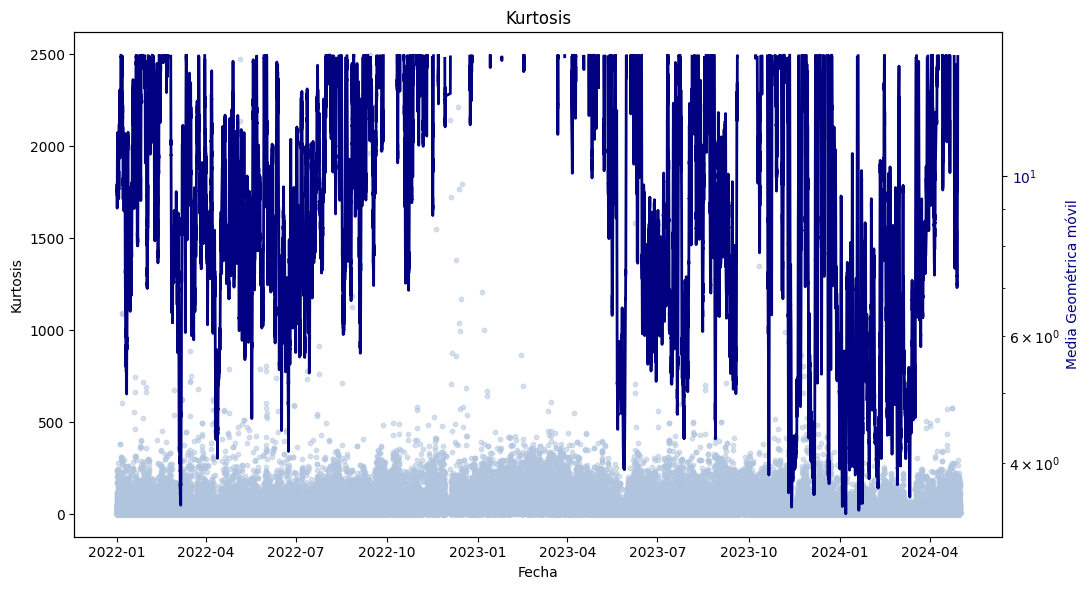

In [145]:
fig2, ax21 = plt.subplots(figsize=(11, 6))
ax22 = ax21.twinx()

# Kurtosis
ax21.scatter(features_df['timestamp'], features_df['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label="Ventana de 10 min")
ax21.set_ylabel('Kurtosis', color='black')
ax21.tick_params(axis='y', labelcolor='black')

# Moving variance
ax22.plot(features_df['timestamp'], features_df['kurtosis_mobile_geom_mean'], color='navy', alpha=1, linewidth=2, label=f'Media móvil centrada ({hours} hr)')
ax22.set_ylabel('Media Geométrica móvil', color='navy')
ax22.tick_params(axis='y', labelcolor='navy')
ax22.set_yscale('log')

ax21.set_title('Kurtosis')
ax21.set_xlabel('Fecha')
plt.xticks(rotation=45)
plt.tight_layout()

In [10]:
fig2, ax21 = plt.subplots(figsize=(11, 6))
ax22 = ax21.twinx()

# Kurtosis
ax21.scatter(features_df['timestamp'], features_df['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label="Ventana de 10 min")
ax21.set_ylabel('Kurtosis', color='black')
ax21.tick_params(axis='y', labelcolor='black')

# Moving variance
ax22.plot(features_df['timestamp'], features_df['kurtosis_mobile_q80'], color='navy', alpha=1, linewidth=2, label=f'Media móvil centrada ({hours} hr)')
ax22.set_ylabel('Cuantil 80 móvil', color='navy')
ax22.tick_params(axis='y', labelcolor='navy')
ax22.set_yscale('log')

ax21.set_title('Kurtosis')
ax21.set_xlabel('Fecha')
plt.xticks(rotation=45)
plt.tight_layout()
fig2.savefig(r"C:/Users/LENOVO/OneDrive/Documentos/Estancia de Investigación/PopocatepetlVolcano/img/Kurtosis_mobile_q80.pdf", bbox_inches="tight", dpi=300)
plt.close(fig2)